# Импорты

In [7]:
import pandas as pd
import numpy as np
import pickle

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.ensemble import (RandomForestRegressor, GradientBoostingRegressor, StackingRegressor, VotingRegressor, 
                              RandomForestClassifier, GradientBoostingClassifier, StackingClassifier, VotingClassifier)
from sklearn.metrics import mean_squared_error, accuracy_score, precision_score, make_scorer
from sklearn.preprocessing import StandardScaler

pd.set_option('display.max_columns', 80)
pd.set_option('display.max_rows', 120)
pd.set_option('display.width', 200)

In [8]:
df = pd.read_csv("../data/epi_r.csv", low_memory=False)
print(f"Исходный размер: {df.shape}")

Исходный размер: (20052, 680)


In [9]:
df = df[df['rating'] > 0].copy().reset_index(drop=True)
print(f"После удаления rating <= 0: {df.shape}")

После удаления rating <= 0: (18216, 680)


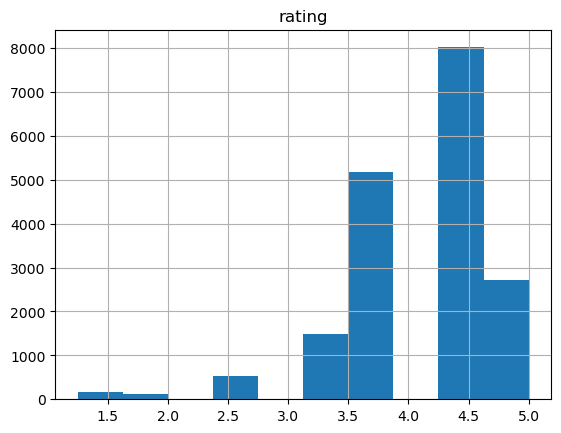

In [10]:
df.hist('rating');

In [11]:
ingredients = [
    'almond', 'amaretto', 'anchovy', 'anise', 'apple', 'apple juice', 'apricot',
    'artichoke', 'arugula', 'asian pear', 'asparagus', 'avocado', 'bacon',
    'banana', 'barley', 'basil', 'bass', 'bean', 'beef', 'beef rib', 'beef shank',
    'beef tenderloin', 'beer', 'beet', 'bell pepper', 'berry', 'biscuit', 'bitters',
    'blackberry', 'blue cheese', 'blueberry', 'bok choy', 'bourbon', 'bran', 'brandy',
    'bread', 'breadcrumbs', 'brie', 'brisket', 'broccoli', 'broccoli rabe',
    'brown rice', 'brownie', 'brussel sprout', 'butter', 'buttermilk', 'butternut squash',
    'cabbage', 'calvados', 'campari', 'candy', 'cantaloupe', 'capers', 'caraway',
    'cardamom', 'carrot', 'cashew', 'cauliflower', 'caviar', 'celery', 'chambord',
    'champagne', 'chard', 'chartreuse', 'cheddar', 'cheese', 'cherry', 'chestnut',
    'chicken', 'chickpea', 'chile', 'chile pepper', 'chili', 'chive', 'chocolate',
    'cilantro', 'cinnamon', 'citrus', 'clam', 'clove', 'coconut', 'cod', 'coffee',
    'collard greens', 'condiment', 'coriander', 'corn', 'cornmeal', 'cottage cheese',
    'couscous', 'crab', 'cranberry', 'cream cheese', 'créme de cacao', 'crêpe',
    'cucumber', 'cumin', 'currant', 'curry', 'custard', 'dairy', 'date', 'dill',
    'duck', 'eau de vie', 'egg', 'egg nog', 'eggplant', 'endive', 'escarole',
    'fennel', 'feta', 'fig', 'fish', 'fontina', 'fortified wine', 'frangelico',
    'garlic', 'gin', 'ginger', 'goat cheese', 'goose', 'gouda', 'grains', 'grand marnier',
    'granola', 'grape', 'grapefruit', 'grappa', 'green bean', 'green onion/scallion',
    'ground beef', 'ground lamb', 'guava', 'halibut', 'ham', 'hazelnut', 'herb',
    'hominy/cornmeal/masa', 'honey', 'honeydew', 'horseradish', 'hot pepper', 'hummus',
    'jalapeño', 'jam', 'jerusalem artichoke', 'jícama', 'kahlúa', 'kale', 'kirsch',
    'kiwi', 'kumquat', 'lamb', 'lamb chop', 'lamb shank', 'lasagna', 'leafy green',
    'leek', 'legume', 'lemon', 'lemon juice', 'lemongrass', 'lentil', 'lettuce',
    'lima bean', 'lime', 'lime juice', 'lingonberry', 'liqueur', 'lobster', 'lychee',
    'macadamia nut', 'mango', 'maple syrup', 'marsala', 'marscarpone', 'marshmallow',
    'mayonnaise', 'meat', 'meatball', 'meatloaf', 'melon', 'mezcal', 'midori',
    'milk/cream', 'mint', 'molasses', 'monterey jack', 'mozzarella', 'mushroom',
    'mussel', 'mustard', 'mustard greens', 'nectarine', 'noodle', 'nut', 'nutmeg',
    'oat', 'oatmeal', 'octopus', 'okra', 'olive', 'onion', 'orange', 'orange juice',
    'oregano', 'orzo', 'oyster', 'papaya', 'paprika', 'parmesan', 'parsley', 'parsnip',
    'passion fruit', 'pasta', 'pea', 'peach', 'peanut', 'peanut butter', 'pear',
    'pecan', 'pepper', 'pernod', 'persimmon', 'phyllo/puff pastry dough', 'pickles',
    'pine nut', 'pineapple', 'pistachio', 'plantain', 'plum', 'poblano', 'pomegranate',
    'pomegranate juice', 'poppy', 'pork', 'pork chop', 'pork rib', 'pork tenderloin',
    'port', 'potato', 'poultry', 'poultry sausage', 'prosciutto', 'prune', 'pumpkin',
    'quail', 'quince', 'quinoa', 'rabbit', 'rack of lamb', 'radicchio', 'radish',
    'raisin', 'raspberry', 'red wine', 'rhubarb', 'rice', 'ricotta', 'rosé', 'rum',
    'rutabaga', 'rye', 'saffron', 'sage', 'sake', 'salmon', 'salsa', 'sardine',
    'sausage', 'scallop', 'scotch', 'seafood', 'seed', 'semolina', 'sesame', 'sesame oil',
    'shallot', 'shellfish', 'sherry', 'shrimp', 'snapper', 'sorbet', 'sour cream',
    'sourdough', 'soy', 'soy sauce', 'sparkling wine', 'spice', 'spinach', 'spirit',
    'squash', 'squid', 'steak', 'stock', 'strawberry', 'sugar snap pea', 'sweet potato/yam',
    'swiss cheese', 'swordfish', 'tamarind', 'tangerine', 'tapioca', 'tarragon', 'tea',
    'tequila', 'thyme', 'tilapia', 'tofu', 'tomatillo', 'tomato', 'tortillas',
    'tree nut', 'triple sec', 'tropical fruit', 'trout', 'tuna', 'turnip', 'vanilla',
    'veal', 'vegetable', 'venison', 'vermouth', 'vinegar', 'vodka', 'walnut', 'wasabi',
    'watercress', 'watermelon', 'wheat/gluten-free', 'whiskey', 'white wine',
    'whole wheat', 'wild rice', 'wine', 'yellow squash', 'yogurt', 'yuca', 'zucchini',
    'turkey'
]

In [12]:
cols_to_keep = [col for col in ingredients if col in df.columns]
df_ingredients = df[cols_to_keep]

print(f"Осталось колонок: {len(df_ingredients.columns)}")
print(df_ingredients.head())

Осталось колонок: 341
   almond  amaretto  anchovy  anise  apple  apple juice  apricot  artichoke  arugula  asian pear  asparagus  avocado  bacon  banana  barley  basil  bass  bean  beef  beef rib  beef shank  \
0     0.0       0.0      0.0    0.0    1.0          0.0      0.0        0.0      0.0         0.0        0.0      0.0    0.0     0.0     0.0    0.0   0.0   1.0   0.0       0.0         0.0   
1     0.0       0.0      0.0    0.0    0.0          0.0      0.0        0.0      0.0         0.0        0.0      0.0    0.0     0.0     0.0    0.0   0.0   0.0   0.0       0.0         0.0   
2     0.0       0.0      0.0    0.0    0.0          0.0      0.0        0.0      0.0         0.0        0.0      0.0    0.0     0.0     0.0    0.0   0.0   0.0   0.0       0.0         0.0   
3     0.0       0.0      0.0    0.0    0.0          0.0      0.0        0.0      0.0         0.0        0.0      0.0    0.0     0.0     0.0    0.0   0.0   0.0   0.0       0.0         0.0   
4     0.0       0.0      0.0

In [13]:
cols_to_keep_series = pd.Series(cols_to_keep)
cols_to_keep_series.to_csv('../data/ingredient_columns.csv', index=False, header=False)

# Регрессия

In [14]:
X = df_ingredients.copy().fillna(0)
y = df['rating']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

def get_rmse(model, X_data, y_true):
    preds = model.predict(X_data)
    return np.sqrt(mean_squared_error(y_true, preds))

print("Размер обучающей выборки:", X_train.shape)
print("Размер тестовой выборки:", X_test.shape)

Размер обучающей выборки: (14572, 341)
Размер тестовой выборки: (3644, 341)


In [15]:
# Наивная модель
mean_rating = y_train.mean()
naive_predictions = [mean_rating] * len(y_test)
rmse_naive = np.sqrt(mean_squared_error(y_test, naive_predictions))

print("Модель: Naive Mean")
print("RMSE:", round(rmse_naive, 4))

Модель: Naive Mean
RMSE: 0.6798


In [16]:
best_models = {}

# Ridge Regression
params_ridge = {'alpha': [0.1, 1.0, 10.0, 100.0]}
grid_ridge = GridSearchCV(Ridge(), params_ridge, cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1)
grid_ridge.fit(X_train, y_train)
rmse_ridge = get_rmse(grid_ridge, X_test, y_test)
best_models['Ridge'] = grid_ridge.best_estimator_

print("Модель: Ridge (Tuned)")
print("Лучшие параметры:", grid_ridge.best_params_)
print("RMSE:", round(rmse_ridge, 4))
print("-" * 30)

# Random Forest
params_rf = {'n_estimators': [50, 100], 'max_depth': [None, 10, 20]}
grid_rf = GridSearchCV(RandomForestRegressor(random_state=42), params_rf, cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1)
grid_rf.fit(X_train, y_train)
rmse_rf = get_rmse(grid_rf, X_test, y_test)
best_models['RandomForest'] = grid_rf.best_estimator_

print("Модель: Random Forest (Tuned)")
print("Лучшие параметры:", grid_rf.best_params_)
print("RMSE:", round(rmse_rf, 4))
print("-" * 30)

# Gradient Boosting
params_gb = {'n_estimators': [50, 100], 'learning_rate': [0.05, 0.1], 'max_depth': [3, 5]}
grid_gb = GridSearchCV(GradientBoostingRegressor(random_state=42), params_gb, cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1)
grid_gb.fit(X_train, y_train)
rmse_gb = get_rmse(grid_gb, X_test, y_test)
best_models['GradientBoosting'] = grid_gb.best_estimator_

print("Модель: Gradient Boosting (Tuned)")
print("Лучшие параметры:", grid_gb.best_params_)
print("RMSE:", round(rmse_gb, 4))

Модель: Ridge (Tuned)
Лучшие параметры: {'alpha': 100.0}
RMSE: 0.6784
------------------------------
Модель: Random Forest (Tuned)
Лучшие параметры: {'max_depth': 20, 'n_estimators': 100}
RMSE: 0.6722
------------------------------
Модель: Gradient Boosting (Tuned)
Лучшие параметры: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
RMSE: 0.6734


In [17]:
# Ансамбли
estimators_list = [
    ('ridge', best_models['Ridge']),
    ('rf', best_models['RandomForest']),
    ('gb', best_models['GradientBoosting'])
]

# Voting Regressor
voting_model = VotingRegressor(estimators=estimators_list, n_jobs=-1)
voting_model.fit(X_train, y_train)
rmse_voting = get_rmse(voting_model, X_test, y_test)

print("Модель: Voting Ensemble")
print("RMSE:", round(rmse_voting, 4))
print("-" * 30)

# Stacking Regressor
stacking_model = StackingRegressor(estimators=estimators_list, final_estimator=Ridge(), cv=5, n_jobs=-1)
stacking_model.fit(X_train, y_train)
rmse_stacking = get_rmse(stacking_model, X_test, y_test)

print("Модель: Stacking Ensemble")
print("RMSE:", round(rmse_stacking, 4))

Модель: Voting Ensemble
RMSE: 0.6709
------------------------------
Модель: Stacking Ensemble
RMSE: 0.6711


In [18]:
# Итоговое сравнение

results = {
    'Naive Mean': rmse_naive,
    'Ridge': rmse_ridge,
    'Random Forest': rmse_rf,
    'Gradient Boosting': rmse_gb,
    'Voting Ensemble': rmse_voting,
    'Stacking Ensemble': rmse_stacking
}

print("Итоговый рейтинг RMSE (чем меньше тем лучше):")
sorted_results = sorted(results.items(), key=lambda x: x[1])

for name, score in sorted_results:
    print(f"{name:20s}: {score:.4f}")

best_name = sorted_results[0][0]
print(f"\nЛучшая модель: {best_name}")

Итоговый рейтинг RMSE (чем меньше тем лучше):
Voting Ensemble     : 0.6709
Stacking Ensemble   : 0.6711
Random Forest       : 0.6722
Gradient Boosting   : 0.6734
Ridge               : 0.6784
Naive Mean          : 0.6798

Лучшая модель: Voting Ensemble


# Классификация

In [19]:
# Функция для бинаризации: округляем и делим на плохие (<=2) и хорошие (>2)
def make_binary(y):
    y_rounded = np.round(y).astype(int)
    return (y_rounded > 2).astype(int)  # 0 = bad (0,1,2), 1 = good (3,4,5)

y_train_bin = make_binary(y_train)
y_test_bin = make_binary(y_test)

print("Распределение классов в train:", np.bincount(y_train_bin))

Распределение классов в train: [  641 13931]


In [20]:
# Наивная модель
most_frequent_class = np.bincount(y_train_bin).argmax()
naive_preds_bin = np.full(len(y_test_bin), most_frequent_class)
naive_acc_bin = accuracy_score(y_test_bin, naive_preds_bin)
print(f"Наивная модель (Accuracy): {naive_acc_bin:.4f}")

Наивная модель (Accuracy): 0.9509


In [21]:
# Сетка параметров
param_grid_rf = {'n_estimators': [50, 100], 'max_depth': [None, 10]}
param_grid_gb = {'n_estimators': [50, 100], 'learning_rate': [0.05, 0.1]}
param_grid_lr = {'C': [0.1, 1.0, 10.0]}

# Random Forest
rf_bin = GridSearchCV(RandomForestClassifier(random_state=42), param_grid_rf, cv=5, scoring='accuracy', n_jobs=-1)
rf_bin.fit(X_train, y_train_bin)
acc_rf_bin = accuracy_score(y_test_bin, rf_bin.predict(X_test))
print(f"Random Forest (Accuracy): {acc_rf_bin:.4f}, Params: {rf_bin.best_params_}")

# Gradient Boosting
gb_bin = GridSearchCV(GradientBoostingClassifier(random_state=42), param_grid_gb, cv=5, scoring='accuracy', n_jobs=-1)
gb_bin.fit(X_train, y_train_bin)
acc_gb_bin = accuracy_score(y_test_bin, gb_bin.predict(X_test))
print(f"Gradient Boosting (Accuracy): {acc_gb_bin:.4f}, Params: {gb_bin.best_params_}")

# Logistic Regression
lr_bin = GridSearchCV(LogisticRegression(max_iter=1000, random_state=42), param_grid_lr, cv=5, scoring='accuracy', n_jobs=-1)
lr_bin.fit(X_train, y_train_bin)
acc_lr_bin = accuracy_score(y_test_bin, lr_bin.predict(X_test))
print(f"Logistic Regression (Accuracy): {acc_lr_bin:.4f}, Params: {lr_bin.best_params_}")

Random Forest (Accuracy): 0.9509, Params: {'max_depth': 10, 'n_estimators': 50}
Gradient Boosting (Accuracy): 0.9512, Params: {'learning_rate': 0.05, 'n_estimators': 50}
Logistic Regression (Accuracy): 0.9509, Params: {'C': 0.1}


In [22]:
# Функция для 3 классов: bad (0,1), so-so (2,3), great (4,5)
def make_three_classes(y):
    y_rounded = np.round(y).astype(int)
    labels = []
    for val in y_rounded:
        if val <= 1:
            labels.append('bad')
        elif val <= 3:
            labels.append('so-so')
        else:
            labels.append('great')
    return np.array(labels)

y_train_tri = make_three_classes(y_train)
y_test_tri = make_three_classes(y_test)

print("Распределение классов в train:")
unique, counts = np.unique(y_train_tri, return_counts=True)
for u, c in zip(unique, counts):
    print(f"{u:10s}: {c}")

Распределение классов в train:
bad       : 124
great     : 12719
so-so     : 1729


In [23]:
# Наивная модель
most_frequent_class_tri = pd.Series(y_train_tri).mode()[0]
naive_preds_tri = np.full(len(y_test_tri), most_frequent_class_tri)
naive_acc_tri = accuracy_score(y_test_tri, naive_preds_tri)
print(f"Наивная модель (Accuracy): {naive_acc_tri:.4f}")

Наивная модель (Accuracy): 0.8749


In [24]:
rf_tri = GridSearchCV(RandomForestClassifier(random_state=42), param_grid_rf, cv=5, scoring='accuracy', n_jobs=-1)
rf_tri.fit(X_train, y_train_tri)
acc_rf_tri = accuracy_score(y_test_tri, rf_tri.predict(X_test))
print(f"Random Forest (Accuracy): {acc_rf_tri:.4f}")

gb_tri = GridSearchCV(GradientBoostingClassifier(random_state=42), param_grid_gb, cv=5, scoring='accuracy', n_jobs=-1)
gb_tri.fit(X_train, y_train_tri)
acc_gb_tri = accuracy_score(y_test_tri, gb_tri.predict(X_test))
print(f"Gradient Boosting (Accuracy): {acc_gb_tri:.4f}")

lr_tri = GridSearchCV(LogisticRegression(max_iter=1000, random_state=42), param_grid_lr, cv=5, scoring='accuracy', n_jobs=-1)
lr_tri.fit(X_train, y_train_tri)
acc_lr_tri = accuracy_score(y_test_tri, lr_tri.predict(X_test))
print(f"Logistic Regression (Accuracy): {acc_lr_tri:.4f}")

Random Forest (Accuracy): 0.8749
Gradient Boosting (Accuracy): 0.8749
Logistic Regression (Accuracy): 0.8743


In [25]:
def precision_great(y_true, y_pred):
    y_true_bin = (y_true == 'great').astype(int)
    y_pred_bin = (y_pred == 'great').astype(int)
    return precision_score(y_true_bin, y_pred_bin, zero_division=0)

scorer = make_scorer(precision_great)

In [26]:
# Переобучаем модели с новой метрикой
rf_tri_p = GridSearchCV(RandomForestClassifier(random_state=42), param_grid_rf, cv=5, scoring=scorer, n_jobs=-1)
rf_tri_p.fit(X_train, y_train_tri)
prec_rf = precision_great(y_test_tri, rf_tri_p.predict(X_test))
print(f"Random Forest (Precision 'great'): {prec_rf:.4f}")

gb_tri_p = GridSearchCV(GradientBoostingClassifier(random_state=42), param_grid_gb, cv=5, scoring=scorer, n_jobs=-1)
gb_tri_p.fit(X_train, y_train_tri)
prec_gb = precision_great(y_test_tri, gb_tri_p.predict(X_test))
print(f"Gradient Boosting (Precision 'great'): {prec_gb:.4f}")

lr_tri_p = GridSearchCV(LogisticRegression(max_iter=1000, random_state=42), param_grid_lr, cv=5, scoring=scorer, n_jobs=-1)
lr_tri_p.fit(X_train, y_train_tri)
prec_lr = precision_great(y_test_tri, lr_tri_p.predict(X_test))
print(f"Logistic Regression (Precision 'great'): {prec_lr:.4f}")

Random Forest (Precision 'great'): 0.8912
Gradient Boosting (Precision 'great'): 0.8752
Logistic Regression (Precision 'great'): 0.8748


In [27]:
# Ансамбли
estimators = [
    ('rf', rf_tri_p.best_estimator_),
    ('gb', gb_tri_p.best_estimator_),
    ('lr', lr_tri_p.best_estimator_)
]

# Voting Classifier
voting = VotingClassifier(estimators=estimators, voting='soft', n_jobs=-1)
voting.fit(X_train, y_train_tri)
prec_voting = precision_great(y_test_tri, voting.predict(X_test))
print(f"Voting Ensemble (Precision 'great'): {prec_voting:.4f}")

# Stacking Classifier
stacking = StackingClassifier(estimators=estimators, final_estimator=LogisticRegression(), cv=5, n_jobs=-1)
stacking.fit(X_train, y_train_tri)
prec_stacking = precision_great(y_test_tri, stacking.predict(X_test))
print(f"Stacking Ensemble (Precision 'great'): {prec_stacking:.4f}")

Voting Ensemble (Precision 'great'): 0.8751
Stacking Ensemble (Precision 'great'): 0.8758


/Users/arthur/miniforge-x86/envs/.venv/lib/python3.8/site-packages/sklearn/linear_model/_logistic.py:762: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [28]:
# Итоговый результаты
print("\nБинарная классификация (Accuracy):")
bin_results = {'RF': acc_rf_bin, 'GB': acc_gb_bin, 'LR': acc_lr_bin}
print(f"Лучшая: {max(bin_results, key=bin_results.get)} ({max(bin_results.values()):.4f})")

print("\nТри модели (Accuracy):")
tri_acc_results = {'RF': acc_rf_tri, 'GB': acc_gb_tri, 'LR': acc_lr_tri}
print(f"Лучшая: {max(tri_acc_results, key=tri_acc_results.get)} ({max(tri_acc_results.values()):.4f})")

print("\nТри модели (Precision для 'great'):")
tri_prec_results = {'RF': prec_rf, 'GB': prec_gb, 'LR': prec_lr}
print(f"Лучшая: {max(tri_prec_results, key=tri_prec_results.get)} ({max(tri_prec_results.values()):.4f})")

print("\nАнсамбли (Precision для 'great'):")
ens_results = {'Voting': prec_voting, 'Stacking': prec_stacking}
print(f"Лучший: {max(ens_results, key=ens_results.get)} ({max(ens_results.values()):.4f})")


Бинарная классификация (Accuracy):
Лучшая: GB (0.9512)

Три модели (Accuracy):
Лучшая: RF (0.8749)

Три модели (Precision для 'great'):
Лучшая: RF (0.8912)

Ансамбли (Precision для 'great'):
Лучший: Stacking (0.8758)


# Выбор и сохранение лучшей модели

In [29]:
best_model = rf_tri_p.best_estimator_  # Random Forest с оптимизацией под Precision 'great'

with open('../data/best_recipe_classifier.pkl', 'wb') as f:
    pickle.dump(best_model, f)

print("Лучшая модель сохранена в файл 'best_recipe_classifier.pkl'")
print(f"Precision для класса 'great': {prec_rf:.4f}")

Лучшая модель сохранена в файл 'best_recipe_classifier.pkl'
Precision для класса 'great': 0.8912


# Генерация nutrition_facts.csv

In [30]:
import re

nutrition_cols_raw = ['calories', 'protein', 'fat', 'sodium']

DV_Standards = {
    'calories': 2000,
    'protein': 50,
    'fat': 78,
    'sodium': 2300
}

nutrition_data = []

for ingredient in cols_to_keep:
    mask = df[ingredient] == 1
    if mask.sum() == 0:
        continue
        
    avg_values = df.loc[mask, nutrition_cols_raw].mean()
    
    row = {'ingredient': ingredient}
    for nutrient in nutrition_cols_raw:
        dv = DV_Standards[nutrient]
        pct = (avg_values[nutrient] / dv) * 100
        row[f'{nutrient}_pct'] = round(pct, 2)
        
    nutrition_data.append(row)

nutrition_df = pd.DataFrame(nutrition_data)
nutrition_df.to_csv('../data/nutrition_facts.csv', index=False)

print(f"Сохранено {len(nutrition_df)} записей в nutrition_facts.csv")
display(nutrition_df.head())

Сохранено 339 записей в nutrition_facts.csv


,ingredient,calories_pct,protein_pct,fat_pct,sodium_pct
0,almond,413.57,294.02,589.45,360.41
1,amaretto,20.84,12.26,27.83,4.70
2,anchovy,16.64,17.26,29.96,15.93
3,anise,19.04,33.17,22.50,22.70
4,apple,361.32,265.92,510.82,323.07


# Генерация similar_recipes.csv

In [31]:
def create_epicurious_url(title):
    if pd.isna(title):
        return None
    slug = title.lower()
    slug = re.sub(r'[^a-z0-9\s-]', '', slug)
    slug = re.sub(r'[\s-]+', '-', slug)
    slug = slug.strip('-')
    return f"https://www.epicurious.com/recipes/food/views/{slug}"

similar_recipes_data = []

for idx, row in df.iterrows():
    title = row.get('title')
    rating = row.get('rating')
    
    if pd.isna(title):
        continue
    
    url = create_epicurious_url(title)
    
    similar_recipes_data.append({
        'recipe_name': title,
        'rating': rating,
        'url': url
    })

similar_df = pd.DataFrame(similar_recipes_data)
similar_df.to_csv('../data/similar_recipes.csv', index=False)

print(f"Сохранено {len(similar_df)} записей в similar_recipes.csv")
display(similar_df.head())

Сохранено 18216 записей в similar_recipes.csv


,recipe_name,rating,url
0,"Lentil, Apple, and Turkey Wrap",2.500,https://www.epicurious.com/recipes/food/views/...
1,Boudin Blanc Terrine with Red Onion Confit,4.375,https://www.epicurious.com/recipes/food/views/...
2,Potato and Fennel Soup Hodge,3.750,https://www.epicurious.com/recipes/food/views/...
3,Mahi-Mahi in Tomato Olive Sauce,5.000,https://www.epicurious.com/recipes/food/views/...
4,Spinach Noodle Casserole,3.125,https://www.epicurious.com/recipes/food/views/...


# Бонус

In [32]:
import os
import re
import pandas as pd
import numpy as np
from itertools import combinations

nutrition_cols = ['calories', 'protein', 'fat', 'sodium']
DV = {'calories': 2000, 'protein': 50, 'fat': 78, 'sodium': 2300}

ing_nutrients = {}
for ing in cols_to_keep:
    mask = df[ing] == 1
    if mask.sum() > 0:
        avg = df.loc[mask, nutrition_cols].mean()
        ing_nutrients[ing] = {
            'p': (avg['protein'] / DV['protein']) * 100,
            'f': (avg['fat'] / DV['fat']) * 100,
            's': (avg['sodium'] / DV['sodium']) * 100,
            'c': (avg['calories'] / DV['calories']) * 100
        }
    else:
        ing_nutrients[ing] = {'p': 0, 'f': 0, 's': 0, 'c': 0}

def guess_meal_type(ingredients):
    """
    Эвристика для определения типа блюда по ингредиентам.
    Возвращает: 'breakfast', 'lunch', 'dinner' или 'any'
    """
    ingredients_lower = [i.lower() for i in ingredients]
    
    breakfast_keywords = ['egg', 'oat', 'pancake', 'waffle', 'cereal', 'yogurt', 'toast', 'bacon', 'sausage', 'coffee', 'juice', 'milk/cream', 'muffin', 'crepe']

    lunch_keywords = ['soup', 'salad', 'sandwich', 'wrap', 'burger', 'pasta', 'noodle', 'rice']
    
    dinner_keywords = ['steak', 'chicken', 'beef', 'pork', 'lamb', 'fish', 'salmon', 'shrimp', 'lobster', 'crab', 'roast', 'braise', 'stew']
    
    b_score = sum(1 for k in breakfast_keywords if any(k in i for i in ingredients_lower))
    l_score = sum(1 for k in lunch_keywords if any(k in i for i in ingredients_lower))
    d_score = sum(1 for k in dinner_keywords if any(k in i for i in ingredients_lower))
    
    if b_score >= l_score and b_score >= d_score and b_score > 0:
        return 'breakfast'
    elif d_score > l_score and d_score > 0:
        return 'dinner'
    elif l_score > 0:
        return 'lunch'
    else:
        return 'any'

menu_data = []
print(f"Обработка {len(df)} рецептов...")

for idx, row in df.iterrows():
    title = row.get('title')
    rating = row.get('rating')
    
    if pd.isna(title) or rating < 1:
        continue
        
    recipe_ings = [col for col in cols_to_keep if row.get(col, 0) == 1]
    
    if not recipe_ings:
        continue
        
    total_p = sum(ing_nutrients.get(i, {}).get('p', 0) for i in recipe_ings)
    total_f = sum(ing_nutrients.get(i, {}).get('f', 0) for i in recipe_ings)
    total_s = sum(ing_nutrients.get(i, {}).get('s', 0) for i in recipe_ings)
    total_c = sum(ing_nutrients.get(i, {}).get('c', 0) for i in recipe_ings)
    
    meal_type = guess_meal_type(recipe_ings)
    
    slug = re.sub(r'[^a-z0-9\s-]', '', str(title).lower())
    slug = re.sub(r'[\s-]+', '-', slug).strip('-')
    url = f"https://www.epicurious.com/recipes/food/views/{slug}"
    
    menu_data.append({
        'title': title,
        'rating': rating,
        'url': url,
        'ingredients': '|'.join(recipe_ings),
        'ingredients_list': recipe_ings,
        'protein_pct': total_p,
        'fat_pct': total_f,
        'sodium_pct': total_s,
        'calories_pct': total_c,
        'meal_type': meal_type
    })

menu_df = pd.DataFrame(menu_data)

menu_df.to_csv('../data/daily_menu_data.pkl', index=False) 
print(f"Распределение типов блюд: {menu_df['meal_type'].value_counts().to_dict()}")

Обработка 18216 рецептов...
Распределение типов блюд: {'any': 7875, 'breakfast': 4821, 'dinner': 4178, 'lunch': 1152}
